# EDA of credit card data

Let's start by importing the necessary libraries. For this eda we will import numpy, pandas, matplotlb and seaborn.

In [187]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

Now lets work on importing the data from the excel file using pandas. we will store this data in a pandas Data Frame. We will also see 5 random data points of this dataset.

In [188]:
data = pd.read_excel("default of credit card clients.xls", header = 1)
data.sample(5)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
10804,10805,120000,2,1,2,26,0,0,0,0,...,15090,16836,18554,1206,1300,2000,2000,2000,2000,0
12689,12690,250000,1,1,2,42,0,0,0,0,...,209124,213392,205180,11300,12177,7200,8000,7700,8003,0
22459,22460,170000,2,2,1,36,2,2,2,2,...,17711,17131,18197,0,2500,1500,0,1500,1000,0
9657,9658,80000,1,1,1,46,0,0,0,0,...,29213,25356,22723,2000,2490,1522,1100,960,988,0
23983,23984,160000,1,2,2,25,0,0,0,0,...,5494,4586,4686,1060,1276,1000,92,100,1000,0


As you can see the data columns aren't clear. We will name them properly before doing anything else.

This is much more better. now as Id columns is useless, lets drop it.

In [189]:
data = data.drop(columns = 'ID')
data.sample(5)

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
20070,200000,2,1,2,31,0,0,0,0,0,...,47301,47232,25231,6018,2507,2011,4140,5072,500,0
21304,260000,1,1,1,50,-2,-2,-2,-2,-2,...,1080,1780,0,7516,553,1080,1780,0,0,0
28131,250000,2,2,1,28,-2,-2,-2,-2,-2,...,0,4501,282,0,0,0,4501,282,10351,0
29637,50000,1,3,2,45,0,0,0,0,-2,...,0,0,0,2356,2150,0,0,0,0,0
25872,180000,2,2,2,33,-1,-1,-1,-1,-1,...,18572,11560,4298,7817,2358,18577,11560,4298,12330,0


In [190]:
data.describe()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


Now let's understand the meaning of the features. After researching, I found that :
- LIMIT_BAL: Amount of the given credit (in NT dollars).
- SEX: Gender (1 = male; 2 = female).
- EDUCATION: Education level (1 = graduate school; 2 = university; 3 = high school; 4 = others; 0, 5, 6 are often grouped into "others/unknown").
- MARRIAGE: Marital status (1 = married; 2 = single; 3 = others).
- AGE: Age in years.
- PAY_0 (or PAY_1), PAY_2, PAY_3, PAY_4, PAY_5, PAY_6: Repayment status for each of the last six months. The values indicate the payment delay:
  - -1 = Pay duly/on time.
  - 0 = No delay.
  - 1 = Payment delay for one month.
  - 2 = Payment delay for two months, etc., up to 9 (nine months and above delay).
- BILL_AMT1 to BILL_AMT6: Amount of bill statement for each of the last six months.
- PAY_AMT1 to PAY_AMT6: Amount of previous payment for each of the last six months.

Now as we know what every feature is, we can explore the data more properly.
Before exploring any feature, lets see if there are any missing values.

In [191]:
data.isna().sum()

LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default payment next month    0
dtype: int64

There seems to be no missing data!

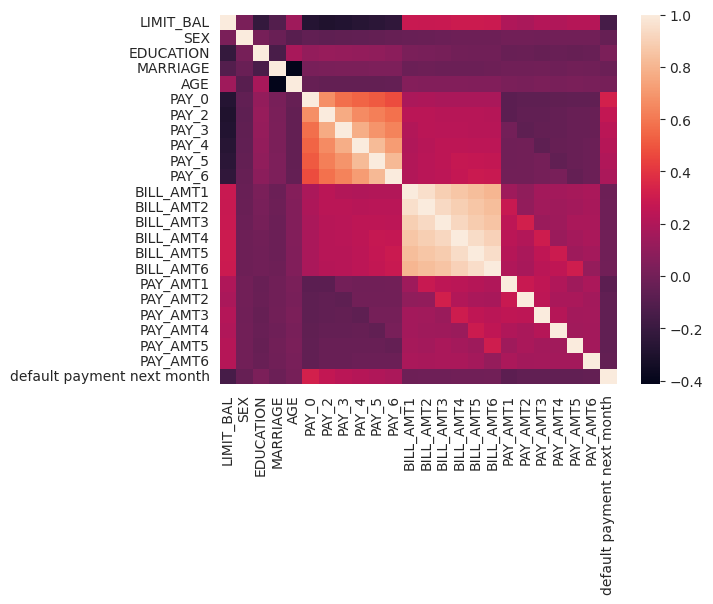

In [192]:
sns.heatmap(data.corr())
plt.show()

In [193]:
print(data.skew(axis = 0))

LIMIT_BAL                      0.992867
SEX                           -0.424183
EDUCATION                      0.970972
MARRIAGE                      -0.018742
AGE                            0.732246
PAY_0                          0.731975
PAY_2                          0.790565
PAY_3                          0.840682
PAY_4                          0.999629
PAY_5                          1.008197
PAY_6                          0.948029
BILL_AMT1                      2.663861
BILL_AMT2                      2.705221
BILL_AMT3                      3.087830
BILL_AMT4                      2.821965
BILL_AMT5                      2.876380
BILL_AMT6                      2.846645
PAY_AMT1                      14.668364
PAY_AMT2                      30.453817
PAY_AMT3                      17.216635
PAY_AMT4                      12.904985
PAY_AMT5                      11.127417
PAY_AMT6                      10.640727
default payment next month     1.343504
dtype: float64


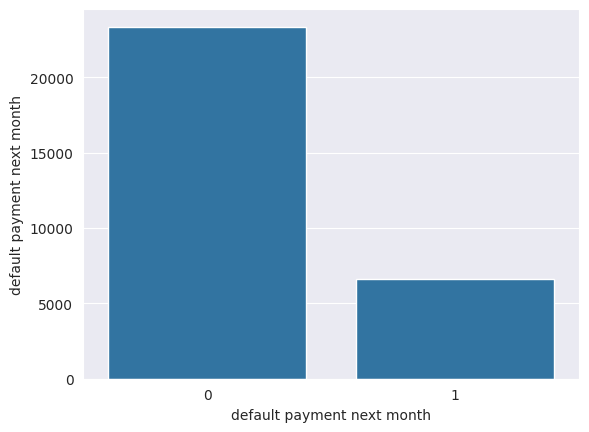

In [194]:
sns.barplot(x = 'default payment next month', y = 'default payment next month',  data = data, estimator = len)
plt.show()

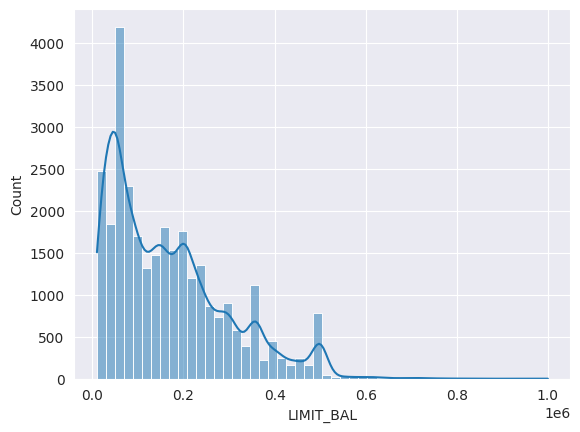

In [195]:
sns.histplot(x = 'LIMIT_BAL', data = data, kde = True, bins = 50)
plt.show()

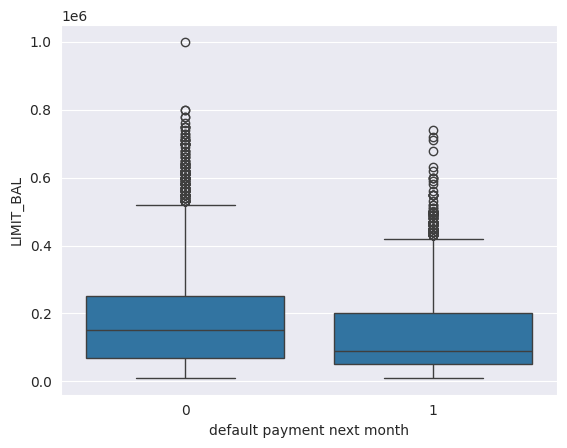

In [196]:
sns.boxplot(y = 'LIMIT_BAL',x = 'default payment next month', data = data)
plt.show()

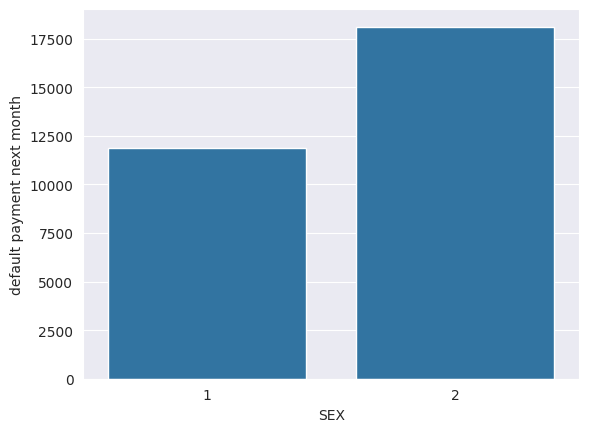

In [197]:
sns.barplot(x = "SEX", y = "default payment next month", data = data, estimator = len)
plt.show()

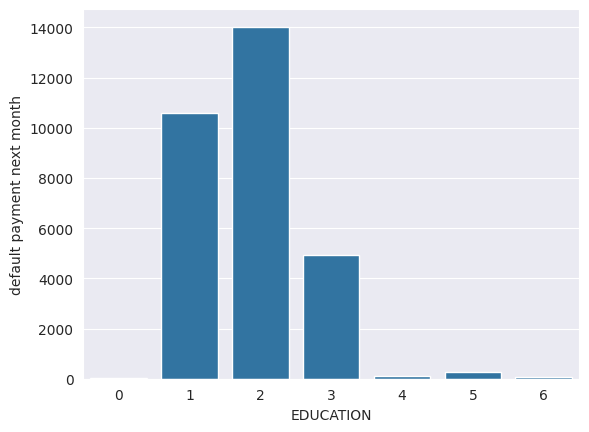

In [198]:
sns.barplot(x = "EDUCATION", y = "default payment next month", data = data, estimator = len)
plt.show()

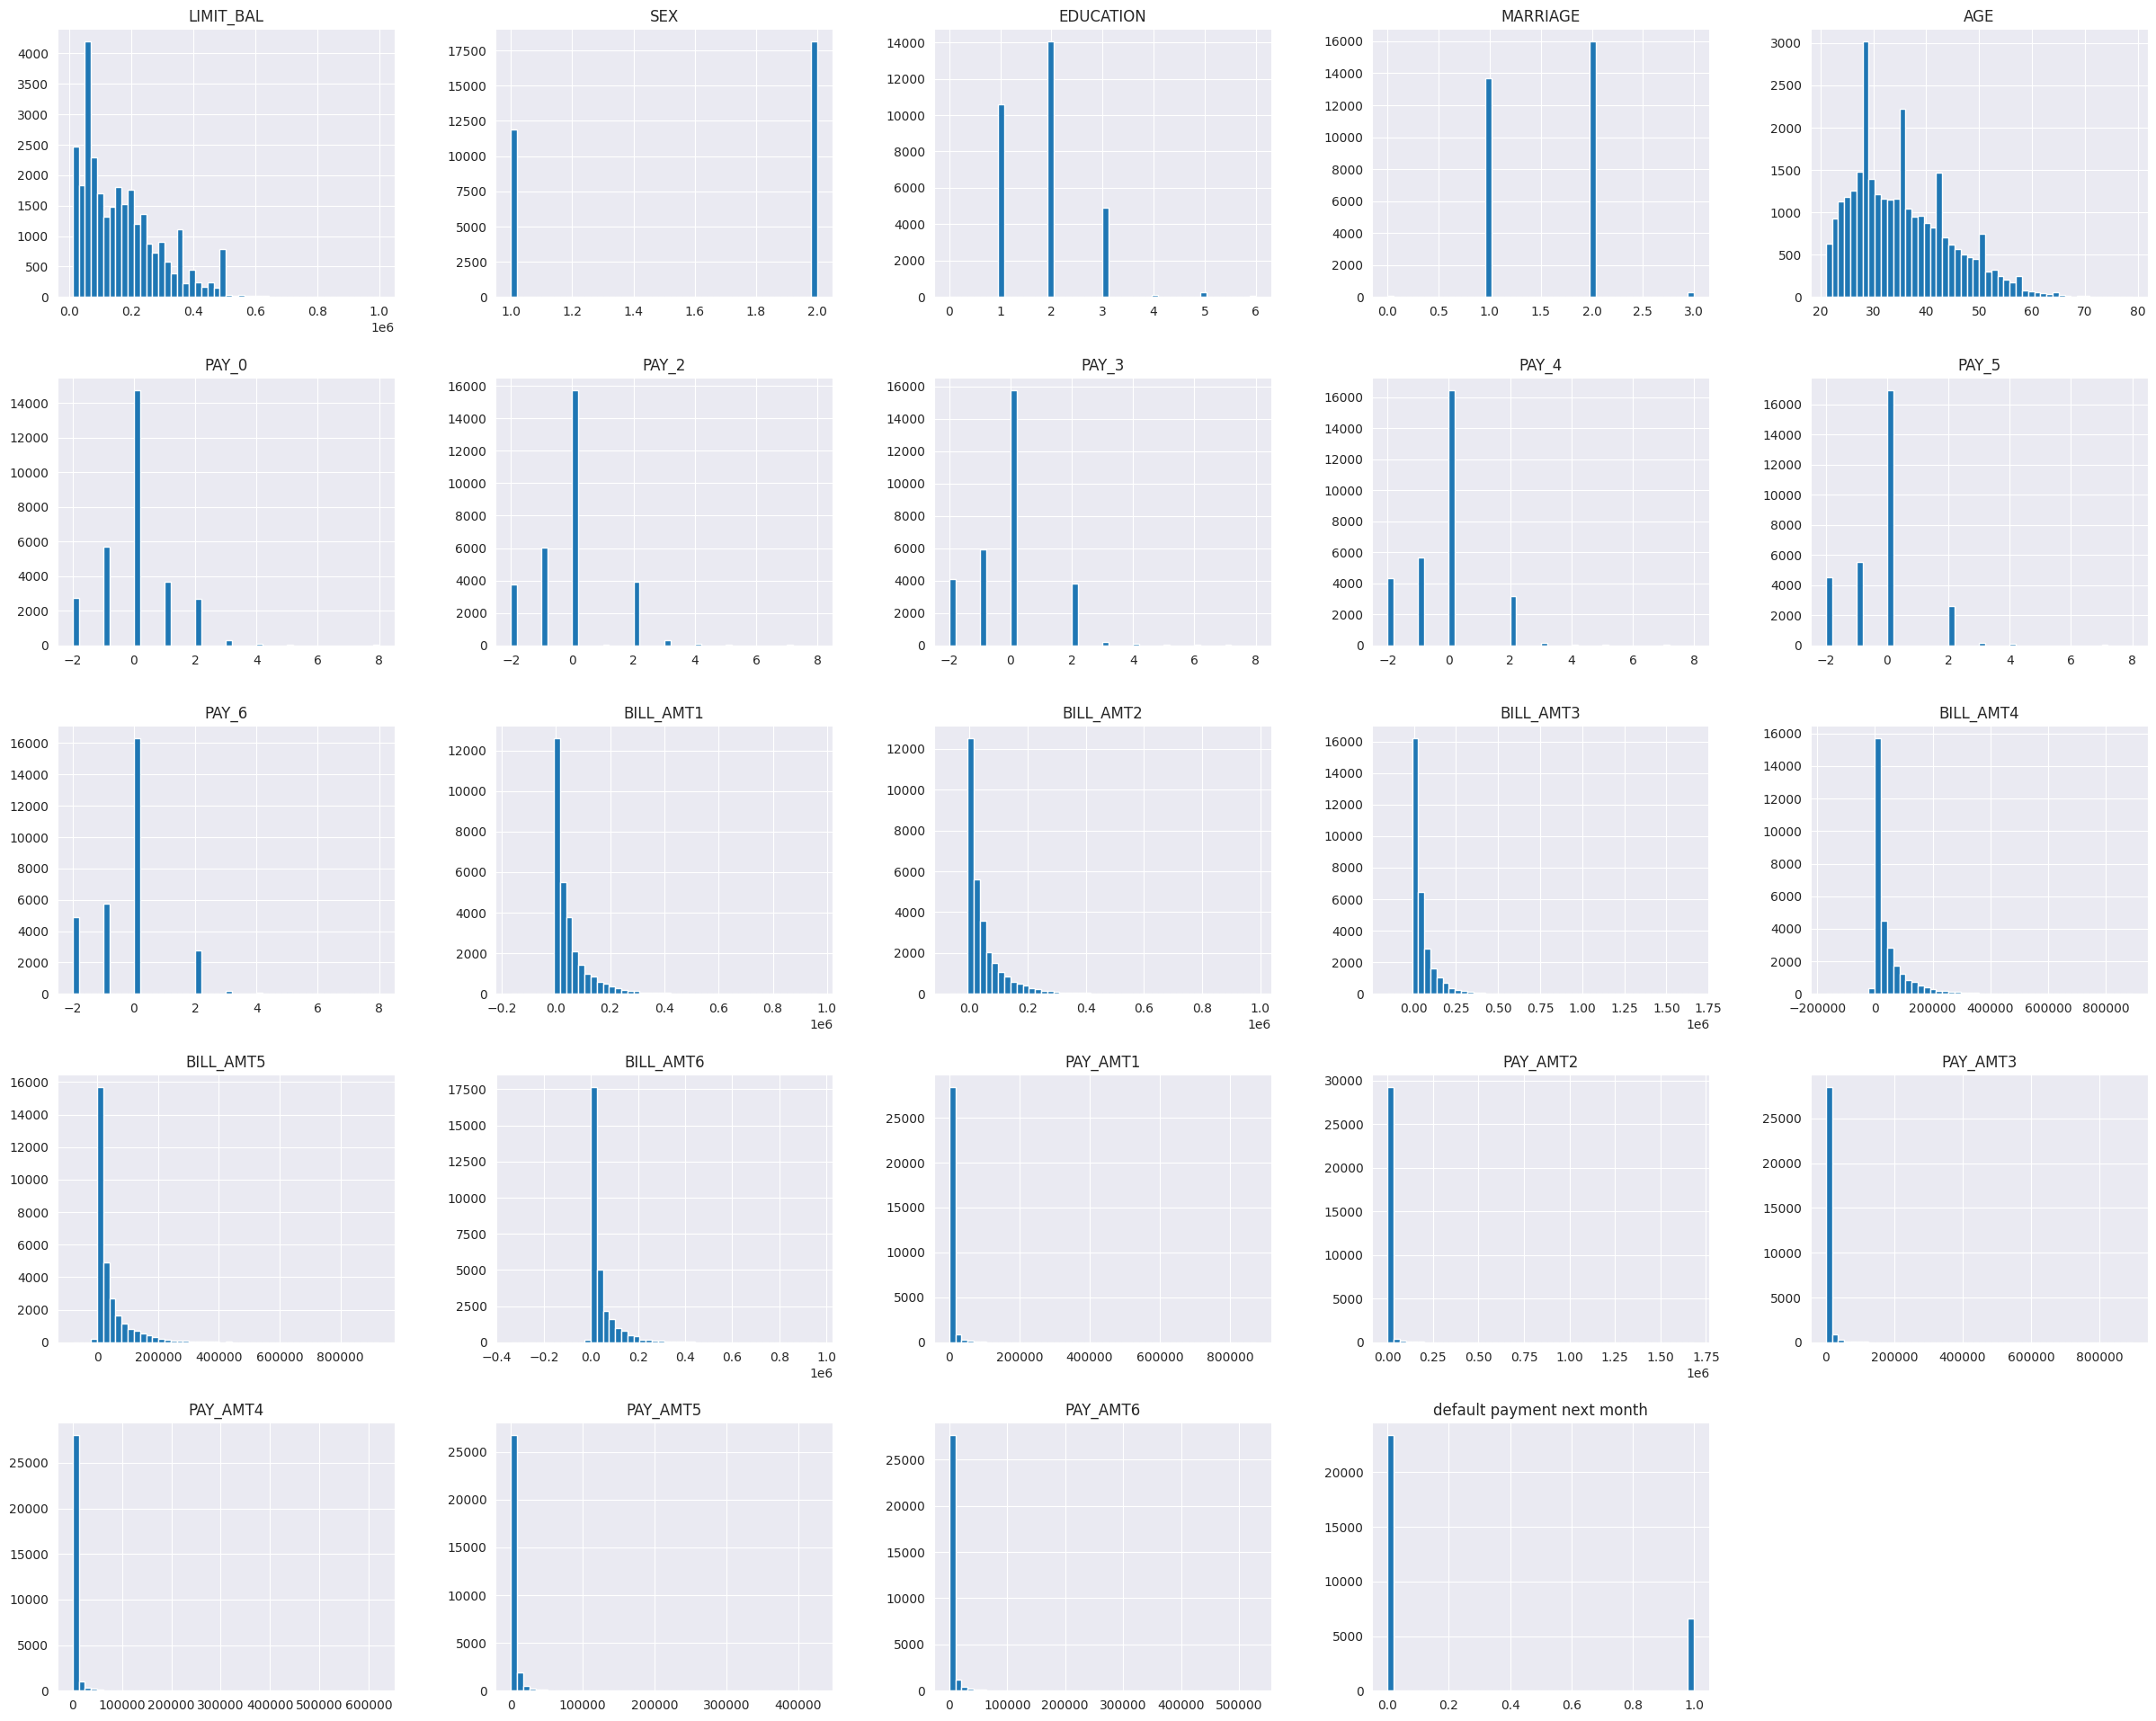

In [199]:
data.hist(figsize=(30, 24), bins=50,layout=(5,5))
plt.show()

In [200]:
data["EDUCATION"].value_counts()/len(data["EDUCATION"])

EDUCATION
2    0.467667
1    0.352833
3    0.163900
5    0.009333
4    0.004100
6    0.001700
0    0.000467
Name: count, dtype: float64

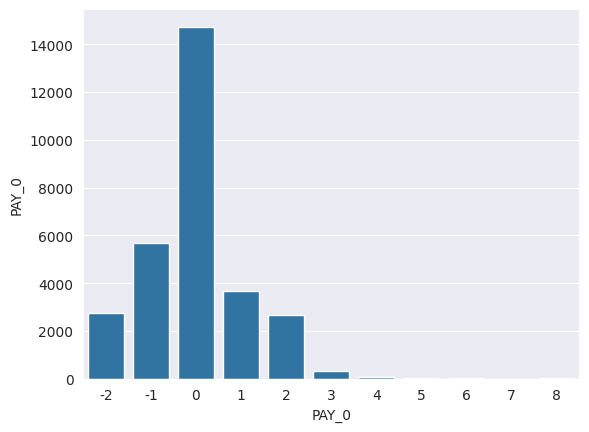

In [201]:
sns.barplot(x = 'PAY_0', y = 'PAY_0',  data = data, estimator = len)
plt.show()

In [202]:
from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np
import pandas as pd

class MinMaxAndYeoJohnson(BaseEstimator, TransformerMixin):

    def __init__(self):
        self.feature_names_out_ = None
        self.X = None
        self.y = None

    def _slope(self, row):
        return np.polyfit(range(len(row)), row, 1)[0]

    def _add_features(self, X):
        X = X.copy()

        # -----------------------
        # DELAY FEATURES
        # -----------------------
        delay_cols = ["PAY_0","PAY_2","PAY_3","PAY_4","PAY_5","PAY_6"]
        X["delay_sum"] = X[delay_cols].sum(axis=1)
        X["max_delay"] = X[delay_cols].max(axis=1)
        X["delay_mean"] = X[delay_cols].mean(axis=1)
        X["delay_std"]  = X[delay_cols].std(axis=1)
        X["delay_trend"] = X[delay_cols].apply(self._slope, axis=1)

        # -----------------------
        # BILL FEATURES
        # -----------------------
        bill_cols = ["BILL_AMT1","BILL_AMT2","BILL_AMT3","BILL_AMT4","BILL_AMT5","BILL_AMT6"]
        X["bill_trend"] = X[bill_cols].apply(self._slope, axis=1)
        X["bill_vol"] = X[bill_cols].std(axis=1)

        # utilization
        X["util1"] = X["BILL_AMT1"] / (X["LIMIT_BAL"] + 1)
        X["util6"] = X["BILL_AMT6"] / (X["LIMIT_BAL"] + 1)
        X["util_trend"] = X[["util1","util6"]].apply(self._slope, axis=1)
        X["util_diff"] = X["util6"] - X["util1"]  # increase = risky

        # -----------------------
        # PAYMENT AMOUNT FEATURES
        # -----------------------
        pay_amt_cols = ["PAY_AMT1","PAY_AMT2","PAY_AMT3","PAY_AMT4","PAY_AMT5","PAY_AMT6"]
        X["pay_amt_trend"] = X[pay_amt_cols].apply(self._slope, axis=1)
        X["pay_vol"] = X[pay_amt_cols].std(axis=1)

        # payment ratios (how much they repay relative to bill)
        X["pay_ratio1"] = X["PAY_AMT1"] / (X["BILL_AMT1"] + 1)
        X["pay_ratio6"] = X["PAY_AMT6"] / (X["BILL_AMT6"] + 1)
        X["pay_ratio_diff"] = X["pay_ratio6"] - X["pay_ratio1"]

        # -----------------------
        # MIXED INTERACTION FEATURES
        # -----------------------
        X["AGE_x_LIMIT_BAL"] = X["AGE"] * X["LIMIT_BAL"]

        top_pairs = [
            ("LIMIT_BAL", "BILL_AMT1"),
            ("LIMIT_BAL", "AGE"),
            ("LIMIT_BAL", "PAY_AMT3"),
            ("LIMIT_BAL", "PAY_AMT6"),
            ("PAY_0", "BILL_AMT1"),
            ("LIMIT_BAL", "PAY_AMT1"),
            ("LIMIT_BAL", "PAY_AMT2"),
            ("LIMIT_BAL", "PAY_AMT4"),
            ("LIMIT_BAL", "PAY_0"),
            ("PAY_0", "PAY_2")
        ]

        for f1, f2 in top_pairs:
            X[f"{f1}_x_{f2}"] = X[f1] * X[f2]

        print(X.isna().sum())
        return X

    def fit(self, X, y=None):
        X_temp = self._add_features(X)
        self.feature_names_out_ = X_temp.columns.tolist()
        self.X = X_temp
        self.y = y
        return self

    def transform(self, X, y=None):
        X_transformed = self._add_features(X)
        return X_transformed

    def get_feature_names_out(self, input_features=None):
        return np.array(self.feature_names_out_, dtype=object)

    def get_train(self):
        print(self.X, self.y)
        return self.X, self.y


In [203]:
TOTAL_DATA_POINTS = 30000
TRAIN_RATIO = 0.7
VAL_RATIO = 0.15
TEST_RATIO = 0.15
TRAIN_POINTS = int(TOTAL_DATA_POINTS * TRAIN_RATIO)
TEST_POINTS = int(TOTAL_DATA_POINTS * TEST_RATIO)
VAL_RATIO = int(TOTAL_DATA_POINTS * VAL_RATIO)

In [204]:
train = data[:TRAIN_POINTS]
test = data[TRAIN_POINTS:TRAIN_POINTS+TEST_POINTS]
val = data[TRAIN_POINTS+TEST_POINTS:]

X_train = train.drop(columns="default payment next month")
y_train = train["default payment next month"]

X_test = test.drop(columns="default payment next month")
y_test = test["default payment next month"]

X_val = val.drop(columns="default payment next month")
y_val = val["default payment next month"]

In [205]:
from imblearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE, RandomOverSampler

In [206]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, precision_recall_fscore_support
from catboost import Pool
params = {
    "depth": 6,
    "learning_rate": 0.03,
    "loss_function": "Logloss",
    "iterations": 1500,
    "l2_leaf_reg": 5,
    "random_strength": 1,
    "border_count": 128,
    "bagging_temperature": 1,
}
model = Pipeline([
('yeo_johnson_and_min_max',MinMaxAndYeoJohnson()),
    ('ROS',RandomOverSampler(sampling_strategy = 'minority')),
('model',CatBoostClassifier(**params,class_weights=[1,3]))
])
model.fit(X_train, y_train)
preds = model.predict(X_test)


LIMIT_BAL                 0
SEX                       0
EDUCATION                 0
MARRIAGE                  0
AGE                       0
PAY_0                     0
PAY_2                     0
PAY_3                     0
PAY_4                     0
PAY_5                     0
PAY_6                     0
BILL_AMT1                 0
BILL_AMT2                 0
BILL_AMT3                 0
BILL_AMT4                 0
BILL_AMT5                 0
BILL_AMT6                 0
PAY_AMT1                  0
PAY_AMT2                  0
PAY_AMT3                  0
PAY_AMT4                  0
PAY_AMT5                  0
PAY_AMT6                  0
delay_sum                 0
max_delay                 0
delay_mean                0
delay_std                 0
delay_trend               0
bill_trend                0
bill_vol                  0
util1                     0
util6                     0
util_trend                0
util_diff                 0
pay_amt_trend             0
pay_vol             

In [207]:
interactions = model.named_steps["model"].get_feature_importance(data=Pool(*list(model.named_steps["yeo_johnson_and_min_max"].get_train())), type='Interaction')
proba = model.predict_proba(X_test)[:,1]
preds = (proba >= 0.5).astype(int)
p, r, f, _ = precision_recall_fscore_support(y_test, preds, average='binary')
print(p,r,f, _)
feature_names = model.named_steps["model"].feature_names_
readable = []

for f1, f2, score in interactions:
    name1 = feature_names[int(f1)]
    name2 = feature_names[int(f2)]
    readable.append([name1, name2, score])

df = pd.DataFrame(readable, columns=["Feature 1", "Feature 2", "Interaction Score"])
print(df.sort_values("Interaction Score", ascending=False).head(20))

       LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0          20000    2          2         1   24      2      2     -1     -1   
1         120000    2          2         2   26     -1      2      0      0   
2          90000    2          2         2   34      0      0      0      0   
3          50000    2          2         1   37      0      0      0      0   
4          50000    1          2         1   57     -1      0     -1      0   
...          ...  ...        ...       ...  ...    ...    ...    ...    ...   
20995      50000    1          2         1   49      1      2      2      0   
20996     230000    1          2         2   38      2      2      2      2   
20997      80000    1          2         1   38      0      0      0      0   
20998     200000    1          2         1   32     -1     -1      0      0   
20999      50000    1          3         1   40     -1     -1     -1     -1   

       PAY_5  ...  LIMIT_BAL_x_BILL_AMT1  LIMIT_BAL

LIMIT_BAL                0
SEX                      0
EDUCATION                0
MARRIAGE                 0
AGE                      0
PAY_0                    0
PAY_2                    0
PAY_3                    0
PAY_4                    0
PAY_5                    0
PAY_6                    0
BILL_AMT1                0
BILL_AMT2                0
BILL_AMT3                0
BILL_AMT4                0
BILL_AMT5                0
BILL_AMT6                0
PAY_AMT1                 0
PAY_AMT2                 0
PAY_AMT3                 0
PAY_AMT4                 0
PAY_AMT5                 0
PAY_AMT6                 0
delay_sum                0
max_delay                0
delay_mean               0
delay_std                0
delay_trend              0
bill_trend               0
bill_vol                 0
util1                    0
util6                    0
util_trend               0
util_diff                0
pay_amt_trend            0
pay_vol                  0
pay_ratio1               1
p

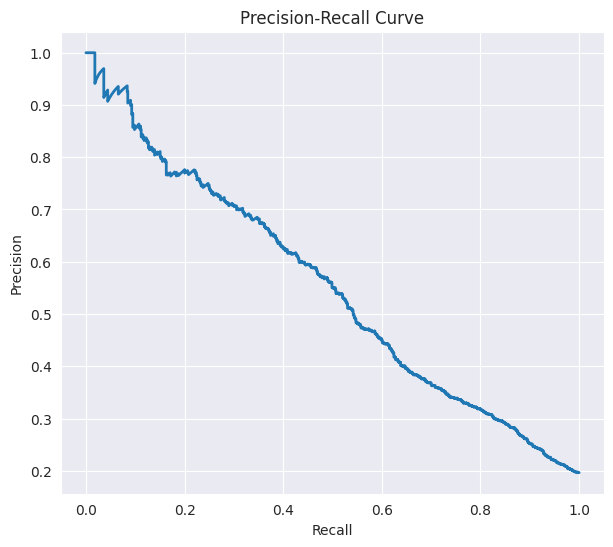

Average Precision Score: 0.54990095962581


In [208]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score
import matplotlib.pyplot as plt

y_scores = model.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

plt.figure(figsize=(7, 6))
plt.plot(recall, precision, linewidth=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.show()

# Optional: Print AP score (area under PR curve)
ap = average_precision_score(y_test, y_scores)
print("Average Precision Score:", ap)


In [209]:
from sklearn.metrics import roc_auc_score
y_test_proba = model.predict_proba(X_test)[:, 1]
score = roc_auc_score(y_test, y_test_proba)
print(score)

LIMIT_BAL                0
SEX                      0
EDUCATION                0
MARRIAGE                 0
AGE                      0
PAY_0                    0
PAY_2                    0
PAY_3                    0
PAY_4                    0
PAY_5                    0
PAY_6                    0
BILL_AMT1                0
BILL_AMT2                0
BILL_AMT3                0
BILL_AMT4                0
BILL_AMT5                0
BILL_AMT6                0
PAY_AMT1                 0
PAY_AMT2                 0
PAY_AMT3                 0
PAY_AMT4                 0
PAY_AMT5                 0
PAY_AMT6                 0
delay_sum                0
max_delay                0
delay_mean               0
delay_std                0
delay_trend              0
bill_trend               0
bill_vol                 0
util1                    0
util6                    0
util_trend               0
util_diff                0
pay_amt_trend            0
pay_vol                  0
pay_ratio1               1
p

In [210]:
from sklearn.metrics import f1_score, precision_recall_curve
import numpy as np

prec, rec, thr = precision_recall_curve(y_test, proba)
f1 = 2 * (prec * rec) / (prec + rec)

best_idx = np.nanargmax(f1)
print("Best threshold:", thr[best_idx])
print("Best F1:", f1[best_idx])
print("Precision:", prec[best_idx])
print("Recall:", rec[best_idx])

Best threshold: 0.7804475939450729
Best F1: 0.5288018433179723
Precision: 0.5387323943661971
Recall: 0.5192307692307693
